<a href="https://colab.research.google.com/github/chenuli949/AI-movie-review-analysis/blob/Dinuri/notebooks/02_1D_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/chenuli949/AI-movie-review-analysis

Cloning into 'AI-movie-review-analysis'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 22 (delta 2), reused 4 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 25.39 MiB | 20.12 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [ ]:
!ls

AI-movie-review-analysis  sample_data


In [ ]:
import os
import numpy as np

path_prefix = "/content/AI-movie-review-analysis/data/"
train_path = path_prefix + "train_indices.npy"
val_path = path_prefix + "validation_indices.npy"
test_path = path_prefix + "test_indices.npy"

# Diagnostic checks
if not os.path.exists(path_prefix):
    print(f"Error: Directory '{path_prefix}' not found by Python.")
    print(f"Contents of /content/: {os.listdir('/content/')}")
elif not os.path.exists(train_path):
    print(f"Error: File '{train_path}' not found by Python in '{path_prefix}'.")
    print(f"Contents of {path_prefix}: {os.listdir(path_prefix)}")

train_idx = np.load(train_path)

val_idx = np.load(val_path)

test_idx = np.load(test_path)

In [ ]:
!ls AI-movie-review-analysis  sample_data

AI-movie-review-analysis:
data  notebooks  README.md

sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


In [ ]:
!ls AI-movie-review-analysis/data

processed_imdb_reviews.csv  train_indices.npy
test_indices.npy	    validation_indices.npy


In [ ]:
import pandas as pd

df = pd.read_csv(
    "AI-movie-review-analysis/data/processed_imdb_reviews.csv"
)

print(df.shape)
df.head()

(50000, 2)


,clean_review,label
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. The filming tec...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [ ]:
df = pd.read_csv("AI-movie-review-analysis/data/processed_imdb_reviews.csv", engine='python', quotechar='"')

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (50000, 2)
                                        clean_review  label
0  One of the other reviewers has mentioned that ...      1
1  A wonderful little production. The filming tec...      1
2  I thought this was a wonderful way to spend ti...      1
3  Basically there's a family where a little boy ...      0
4  Petter Mattei's "Love in the Time of Money" is...      1


In [ ]:
print(df.columns)

Index(['clean_review', 'label'], dtype='object')


In [ ]:
print(df["label"].value_counts())

label
1    25000
0    25000
Name: count, dtype: int64


In [ ]:
print("Training samples:", len(train_idx))
print("Validation samples:", len(val_idx))
print("Test samples:", len(test_idx))

Training samples: 40000
Validation samples: 5000
Test samples: 5000


In [ ]:
X = df["clean_review"].values
y = df["label"].values

In [ ]:
X_train = X[train_idx]
y_train = y[train_idx]

X_val = X[val_idx]
y_val = y[val_idx]

X_test = X[test_idx]
y_test = y[test_idx]

In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (40000,)
y_train: (40000,)
X_val: (5000,)
y_val: (5000,)
X_test: (5000,)
y_test: (5000,)


In [ ]:
MAX_VOCAB_SIZE = 20000
SEQUENCE_LENGTH = 300
EMBEDDING_DIM = 128

In [ ]:
vectorizer = layers.TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH
)

In [ ]:
vectorizer.adapt(X_train)

In [ ]:
print("Vocabulary size:", len(vectorizer.get_vocabulary()))

Vocabulary size: 20000


In [ ]:
X_train_vectorized = vectorizer(X_train)
X_val_vectorized = vectorizer(X_val)
X_test_vectorized = vectorizer(X_test)

In [ ]:
print("Training:", X_train_vectorized.shape)
print("Validation:", X_val_vectorized.shape)
print("Test:", X_test_vectorized.shape)

Training: (40000, 300)
Validation: (5000, 300)
Test: (5000, 300)


In [ ]:
model = models.Sequential([

    layers.Input(shape=(SEQUENCE_LENGTH,)),

    layers.Embedding(
        input_dim=MAX_VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    layers.Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu"
    ),

    layers.MaxPooling1D(
        pool_size=2
    ),

    layers.Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu"
    ),

    layers.GlobalMaxPooling1D(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 296, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 148, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 144, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,732,417 (10.42 MB)

 Trainable params: 2,732,417 (10.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train_vectorized,
    y_train,
    validation_data=(X_val_vectorized, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.7791 - loss: 0.4364 - val_accuracy: 0.8742 - val_loss: 0.2903
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9147 - loss: 0.2251 - val_accuracy: 0.8514 - val_loss: 0.4111
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9552 - loss: 0.1316 - val_accuracy: 0.8628 - val_loss: 0.4627


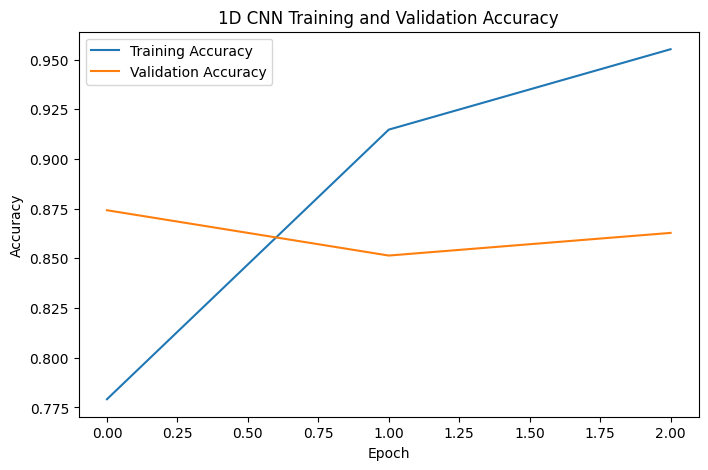

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("1D CNN Training and Validation Accuracy")
plt.legend()
plt.show()

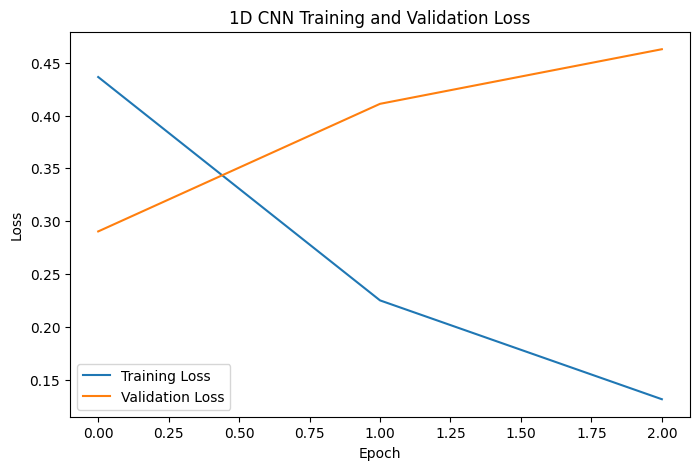

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("1D CNN Training and Validation Loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test_vectorized,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8688 - loss: 0.3022
Test Loss: 0.30224502086639404
Test Accuracy: 0.8687999844551086


In [ ]:
y_pred_probability = model.predict(
    X_test_vectorized
)


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
y_pred = (
    y_pred_probability >= 0.5
).astype(int).flatten()

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8688
Precision: 0.8984442523768367
Recall   : 0.8316
F1 Score : 0.8637307852098047


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.84      0.91      0.87      2500
    Positive       0.90      0.83      0.86      2500

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000



In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[2265  235]
 [ 421 2079]]


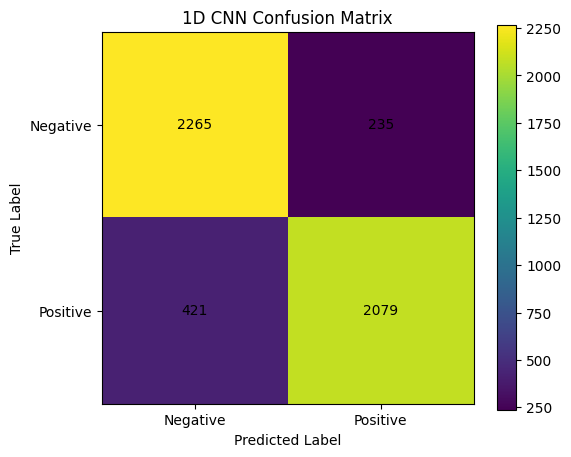

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("1D CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0, 1],
    ["Negative", "Positive"]
)

plt.yticks(
    [0, 1],
    ["Negative", "Positive"]
)

plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [ ]:
cnn_results = pd.DataFrame({
    "Model": ["1D CNN"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1]
})

cnn_results

,Model,Accuracy,Precision,Recall,F1 Score
0,1D CNN,0.8688,0.898444,0.8316,0.863731


In [ ]:
print("Number of epochs actually trained:", len(history.history["loss"]))
print("Best validation loss epoch:", np.argmin(history.history["val_loss"]) + 1)
print("Best validation loss:", min(history.history["val_loss"]))
print("Best validation accuracy:", max(history.history["val_accuracy"]))

Number of epochs actually trained: 3
Best validation loss epoch: 1
Best validation loss: 0.29033997654914856
Best validation accuracy: 0.8741999864578247


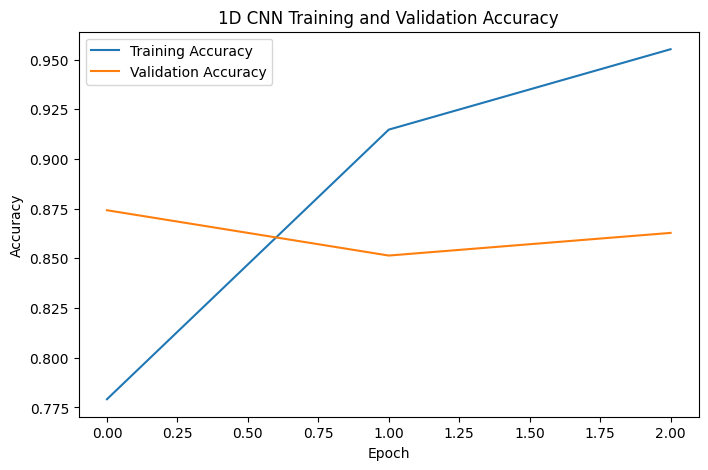

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("1D CNN Training and Validation Accuracy")
plt.legend()

plt.savefig("cnn_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

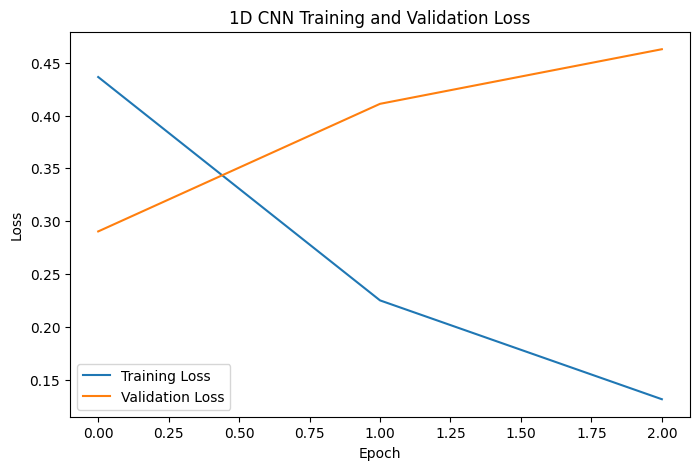

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("1D CNN Training and Validation Loss")
plt.legend()

plt.savefig("cnn_loss.png", dpi=300, bbox_inches="tight")
plt.show()

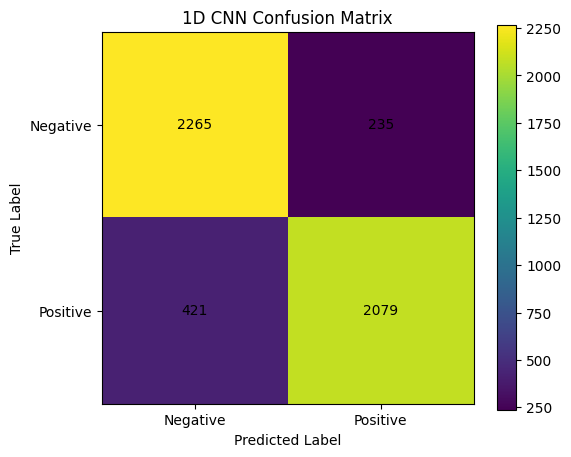

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("1D CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(
            j, i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.savefig(
    "cnn_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
cnn_results.to_csv(
    "cnn_results.csv",
    index=False
)